In [24]:
from datetime import datetime
import socket

start = datetime.now()
print(f"Start time: {start}")
print(f"Host name: {socket.gethostname()}")

Start time: 2025-12-18 10:41:42.401711
Host name: nid007026


# Generate and Visualize Augmented Datasets

This notebook
- calls the CLI script `scripts-lm/augmentation.py` to generate the five augmentation variants (rotation, scaling, sheering, translation, deformation), and
- visualizes the effect of each augmentation on a selected sample from the raw training data.


In [25]:
# Environment and path setup
from pathlib import Path
import sys

# Assume this notebook lives in notebooks-lm under the project root
current_dir = Path.cwd()
BASE_PATH = current_dir.parent

SRC_PATH = BASE_PATH / 'src'
SCRIPTS_PATH = BASE_PATH / 'scripts-lm'
RAW_DATA_PATH = BASE_PATH / 'data' / 'raw'
AUGMENTED_DATA_PATH = BASE_PATH / 'data' / 'augmented'

# Ensure src on sys.path (if we want to reuse project utilities later)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

print(f"Base path: {BASE_PATH}")
print(f"Scripts path: {SCRIPTS_PATH}")
print(f"Raw data path: {RAW_DATA_PATH}")
print(f"Augmented data path: {AUGMENTED_DATA_PATH}")


Base path: /users/lmantel/lab
Scripts path: /users/lmantel/lab/scripts-lm
Raw data path: /users/lmantel/lab/data/raw
Augmented data path: /users/lmantel/lab/data/augmented


In [26]:
# Imports for running the augmentation script and visualization
import subprocess
import gzip
import pickle

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Reuse helper for gzipped pickle IO

def load_zipped_pickle(filename):
    with gzip.open(filename, 'rb') as f:
        loaded_object = pickle.load(f)
        return loaded_object


def save_zipped_pickle(obj, filename):
    with gzip.open(filename, 'wb') as f:
        pickle.dump(obj, f, 2)


In [27]:
# Configuration for augmentation generation

AUGMENTATION_CONFIGS = [
    {"strategy": "rotation",    "output": AUGMENTED_DATA_PATH / "train-rotation.pkl"},
    {"strategy": "scaling",     "output": AUGMENTED_DATA_PATH / "train-scaling.pkl"},
    {"strategy": "sheering",    "output": AUGMENTED_DATA_PATH / "train-sheering.pkl"},
    {"strategy": "translation", "output": AUGMENTED_DATA_PATH / "train-translation.pkl"},
    {"strategy": "deformation", "output": AUGMENTED_DATA_PATH / "train-deformation.pkl"},
]

NUM_AUGMENTATIONS_PER_SAMPLE = 1
SEED = 42

print("Augmentation configs:")
for cfg in AUGMENTATION_CONFIGS:
    print(f"  - {cfg['strategy']}: {cfg['output']}")


Augmentation configs:
  - rotation: /users/lmantel/lab/data/augmented/train-rotation.pkl
  - scaling: /users/lmantel/lab/data/augmented/train-scaling.pkl
  - sheering: /users/lmantel/lab/data/augmented/train-sheering.pkl
  - translation: /users/lmantel/lab/data/augmented/train-translation.pkl
  - deformation: /users/lmantel/lab/data/augmented/train-deformation.pkl


In [28]:
# Run scripts-lm/augmentation.py for all configured strategies

from pathlib import Path
import sys

AUGMENT_SCRIPT = SCRIPTS_PATH / "augmentation.py"
OVERWRITE_EXISTING = True
DRY_RUN = False

if not AUGMENT_SCRIPT.exists():
    raise FileNotFoundError(f"Augmentation script not found: {AUGMENT_SCRIPT}")


def run_augmentation_script(strategy: str, output_path: Path, num_augmentations: int = 1, seed: int = 42, dry_run: bool = False):
    """Call the CLI augmentation script with the given configuration.

    This uses the current Python executable (sys.executable) to ensure the
    same environment/venv is used as for this notebook.
    """
    cmd = [
        sys.executable,
        str(AUGMENT_SCRIPT),
        "--strategy", strategy,
        "--output", str(output_path),
        "--num-augmentations", str(num_augmentations),
        "--seed", str(seed),
    ]
    if dry_run:
        cmd.append("--dry-run")
    print(f"\nRunning: {' '.join(cmd)}")
    result = subprocess.run(cmd, cwd=str(BASE_PATH))
    if result.returncode != 0:
        raise RuntimeError(f"Augmentation script failed for strategy={strategy} (exit code {result.returncode})")

for cfg in AUGMENTATION_CONFIGS:
    strategy = cfg["strategy"]
    output_path = cfg["output"]
    if not OVERWRITE_EXISTING and output_path.exists():
        print(f"Skipping {strategy}: {output_path} already exists")
        continue
    run_augmentation_script(
        strategy=strategy,
        output_path=output_path,
        num_augmentations=NUM_AUGMENTATIONS_PER_SAMPLE,
        seed=SEED,
        dry_run=DRY_RUN,
    )

print("\nAll requested augmentations are available.")



Running: /users/lmantel/lab/.venv/bin/python /users/lmantel/lab/scripts-lm/augmentation.py --strategy rotation --output /users/lmantel/lab/data/augmented/train-rotation.pkl --num-augmentations 1 --seed 42
Base path: /users/lmantel/lab
Input path: /users/lmantel/lab/data/raw/train.pkl
Output path: /users/lmantel/lab/data/augmented/train-rotation.pkl
Strategy: rotation
Num augmentations per sample: 1
Seed: 42
Using device: cuda
Dry run: False

Loading training data...
Loaded 65 samples.
Generating 1 augmented samples per original (65 augmented samples in total)...


Augmenting samples: 100%|██████████| 65/65 [00:21<00:00,  2.96it/s]


Final augmented dataset size: 65 (augmented only, originals not included)
Saving augmented data...
Done.

Running: /users/lmantel/lab/.venv/bin/python /users/lmantel/lab/scripts-lm/augmentation.py --strategy scaling --output /users/lmantel/lab/data/augmented/train-scaling.pkl --num-augmentations 1 --seed 42
Base path: /users/lmantel/lab
Input path: /users/lmantel/lab/data/raw/train.pkl
Output path: /users/lmantel/lab/data/augmented/train-scaling.pkl
Strategy: scaling
Num augmentations per sample: 1
Seed: 42
Using device: cuda
Dry run: False

Loading training data...
Loaded 65 samples.
Generating 1 augmented samples per original (65 augmented samples in total)...


Augmenting samples: 100%|██████████| 65/65 [00:22<00:00,  2.95it/s]


Final augmented dataset size: 65 (augmented only, originals not included)
Saving augmented data...
Done.

Running: /users/lmantel/lab/.venv/bin/python /users/lmantel/lab/scripts-lm/augmentation.py --strategy sheering --output /users/lmantel/lab/data/augmented/train-sheering.pkl --num-augmentations 1 --seed 42
Base path: /users/lmantel/lab
Input path: /users/lmantel/lab/data/raw/train.pkl
Output path: /users/lmantel/lab/data/augmented/train-sheering.pkl
Strategy: sheering
Num augmentations per sample: 1
Seed: 42
Using device: cuda
Dry run: False

Loading training data from /users/lmantel/lab/data/raw/train.pkl ...
Loaded 65 samples.
Generating 1 augmented samples per original (65 augmented samples in total)...


...

Final augmented dataset size: 65 (augmented only, originals not included)
Saving augmented data to /users/lmantel/lab/data/augmented/train-sheering.pkl ...
Done.

Running: /users/lmantel/lab/.venv/bin/python /users/lmantel/lab/scripts-lm/augmentation.py --strategy translation --output /users/lmantel/lab/data/augmented/train-translation.pkl --num-augmentations 1 --seed 42
Base path: /users/lmantel/lab
Input path: /users/lmantel/lab/data/raw/train.pkl
Output path: /users/lmantel/lab/data/augmented/train-translation.pkl
Strategy: translation
Num augmentations per sample: 1
Seed: 42
Using device: cuda
Dry run: False

Loading training data from /users/lmantel/lab/data/raw/train.pkl ...
Loaded 65 samples.
Generating 1 augmented samples per original (65 augmented samples in total)...


Augmenting samples: 100%|██████████| 65/65 [00:21<00:00,  3.03it/s]


Final augmented dataset size: 65 (augmented only, originals not included)
Saving augmented data to /users/lmantel/lab/data/augmented/train-translation.pkl ...
Done.

Running: /users/lmantel/lab/.venv/bin/python /users/lmantel/lab/scripts-lm/augmentation.py --strategy deformation --output /users/lmantel/lab/data/augmented/train-deformation.pkl --num-augmentations 1 --seed 42
Base path: /users/lmantel/lab
Input path: /users/lmantel/lab/data/raw/train.pkl
Output path: /users/lmantel/lab/data/augmented/train-deformation.pkl
Strategy: deformation
Num augmentations per sample: 1
Seed: 42
Using device: cuda
Dry run: False

Loading training data from /users/lmantel/lab/data/raw/train.pkl ...
Loaded 65 samples.
Generating 1 augmented samples per original (65 augmented samples in total)...


Augmenting samples:   0%|          | 0/65 [00:00<?, ?it/s]
Traceback (most recent call last):
  File "/users/lmantel/lab/scripts-lm/augmentation.py", line 553, in <module>
    main()
  File "/users/lmantel/lab/scripts-lm/augmentation.py", line 538, in main
    aug_sample = augment_sample_single_strategy(sample, args.strategy, device=device)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/users/lmantel/lab/scripts-lm/augmentation.py", line 403, in augment_sample_single_strategy
    frame_def, mask_def = apply_deformation_grid(frame, mask)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/users/lmantel/lab/scripts-lm/augmentation.py", line 318, in apply_deformation_grid
    deformed = elasticdeform.deform_random_grid(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/users/lmantel/lab/.venv/lib/python3.12/site-packages/elasticdeform/deform_grid.py", line 49, in deform_random_grid
    return deform_grid(X, displac

RuntimeError: Augmentation script failed for strategy=deformation (exit code 1)

In [ ]:
# Load raw data and one example sample

raw_train_path = RAW_DATA_PATH / 'train.pkl'
raw_data = load_zipped_pickle(str(raw_train_path))
print(f"Loaded raw training data: {len(raw_data)} samples")

# Pick one example sample for visualization (you can change the index)
EXAMPLE_INDEX = 0
example_sample = raw_data[EXAMPLE_INDEX]
example_name = example_sample.get('name')
print(f"Using example sample index {EXAMPLE_INDEX} with name: {example_name}")

video = example_sample['video']  # (H, W, T)
label = example_sample['label']  # (H, W, T)
H, W, T = video.shape
mid_t = example_sample['frames'][len(example_sample['frames']) // 2] if example_sample.get('frames') else T // 2
print(f"Middle frame index for visualization: {mid_t}")


Loaded raw training data: 65 samples
Using example sample index 0 with name: D47OR19ANJ
Middle frame index for visualization: 59


In [ ]:
# Load one matching augmented sample per strategy for the chosen example

augmented_examples = {}

for cfg in AUGMENTATION_CONFIGS:
    strategy = cfg["strategy"]
    path = cfg["output"]
    data = load_zipped_pickle(str(path))
    print(f"Loaded {len(data)} augmented samples for {strategy} from {path}")

    # Find first augmented sample that corresponds to the chosen example (by base name prefix)
    target_prefix = f"{example_name}_{strategy}_"
    match = None
    for s in data:
        name = s.get('name', '')
        if name.startswith(target_prefix):
            match = s
            break
    if match is None:
        print(f"  WARNING: No augmented sample found for {example_name} with strategy {strategy}")
    else:
        augmented_examples[strategy] = match
        print(f"  -> Using augmented sample: {match.get('name')}")


Loaded 65 augmented samples for rotation from /users/lmantel/lab/data/augmented/train-rotation.pkl
  -> Using augmented sample: D47OR19ANJ_rotation_aug1
Loaded 65 augmented samples for scaling from /users/lmantel/lab/data/augmented/train-scaling.pkl
  -> Using augmented sample: D47OR19ANJ_scaling_aug1
Loaded 65 augmented samples for sheering from /users/lmantel/lab/data/augmented/train-sheering.pkl
  -> Using augmented sample: D47OR19ANJ_sheering_aug1
Loaded 65 augmented samples for translation from /users/lmantel/lab/data/augmented/train-translation.pkl
  -> Using augmented sample: D47OR19ANJ_translation_aug1
Loaded 65 augmented samples for deformation from /users/lmantel/lab/data/augmented/train-deformation.pkl
  -> Using augmented sample: D47OR19ANJ_deformation_aug1


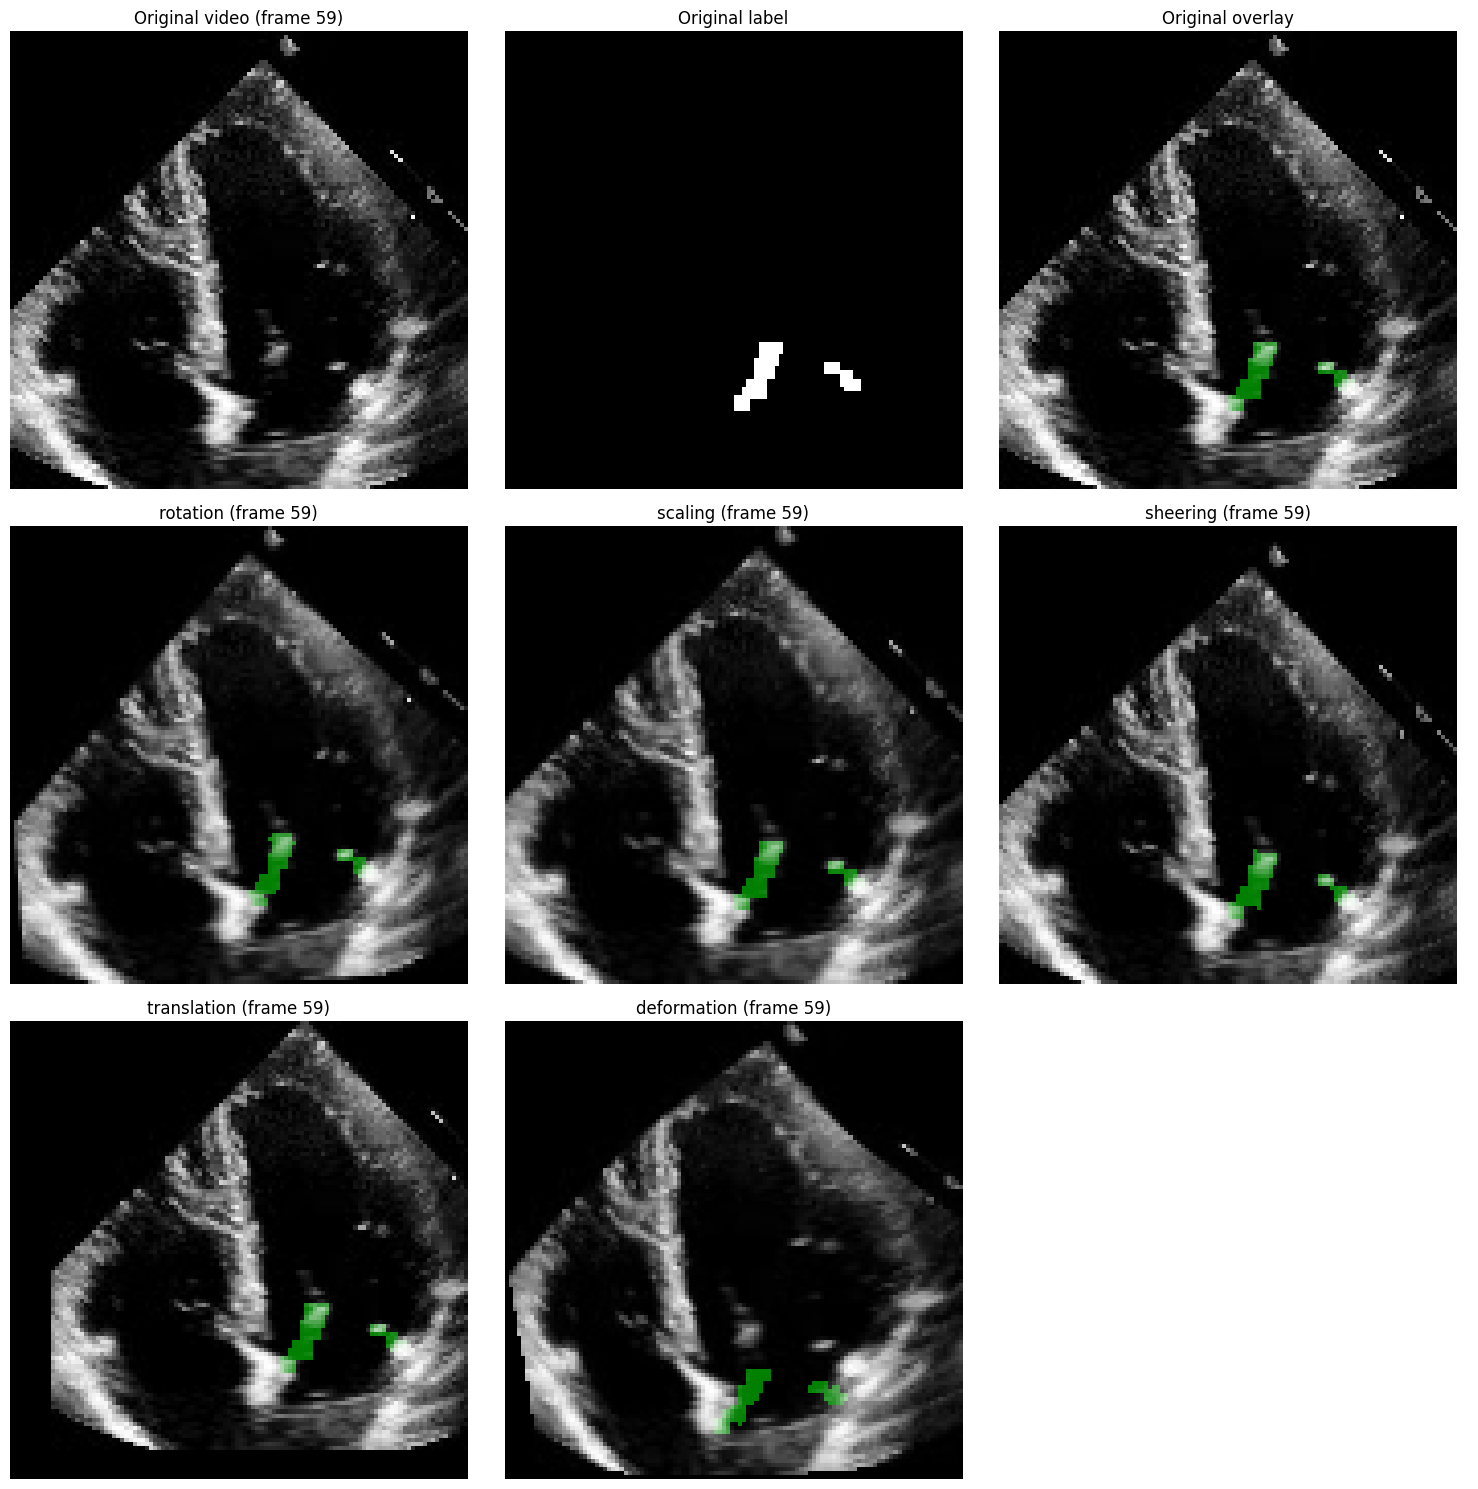

In [ ]:
# Visualize original vs. each augmentation (single frame)

strategies_to_show = [cfg["strategy"] for cfg in AUGMENTATION_CONFIGS]

# Prepare original overlays
orig_frame = video[:, :, mid_t]
orig_mask = label[:, :, mid_t]

# Single 3x3 figure: first row original, remaining rows augmentations
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Row 0: original
axes[0, 0].imshow(orig_frame, cmap='gray')
axes[0, 0].set_title(f"Original video (frame {mid_t})")
axes[0, 0].axis('off')

axes[0, 1].imshow(orig_mask, cmap='gray')
axes[0, 1].set_title("Original label")
axes[0, 1].axis('off')

overlay_orig = np.stack([orig_frame, orig_frame, orig_frame], axis=-1)
overlay_orig = overlay_orig.astype(np.float32)
overlay_orig[:, :, 1] = np.where(orig_mask, overlay_orig[:, :, 1] * 0.5 + 255 * 0.5, overlay_orig[:, :, 1])
axes[0, 2].imshow(overlay_orig.astype(np.uint8))
axes[0, 2].set_title("Original overlay")
axes[0, 2].axis('off')

# Rows 1-2: all augmentations (some cells may remain empty if fewer than 6)
for idx, strategy in enumerate(strategies_to_show):
    row = 1 + idx // 3
    col = idx % 3
    ax = axes[row, col]

    aug_sample = augmented_examples.get(strategy)
    if aug_sample is None:
        ax.set_title(f"{strategy}: not found")
        ax.axis('off')
        continue

    aug_video = aug_sample['video']
    aug_label = aug_sample['label']
    H_a, W_a, T_a = aug_video.shape
    # Try to use a frame index consistent with original if possible
    t_idx = mid_t if mid_t < T_a else T_a // 2

    frame_a = aug_video[:, :, t_idx]
    mask_a = aug_label[:, :, t_idx]

    overlay_a = np.stack([frame_a, frame_a, frame_a], axis=-1).astype(np.float32)
    overlay_a[:, :, 1] = np.where(mask_a, overlay_a[:, :, 1] * 0.5 + 255 * 0.5, overlay_a[:, :, 1])

    ax.imshow(overlay_a.astype(np.uint8))
    ax.set_title(f"{strategy} (frame {t_idx})")
    ax.axis('off')

# Hide any unused cells (if fewer than 6 augmentations)
for idx in range(len(strategies_to_show), 6):
    row = 1 + idx // 3
    col = idx % 3
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
end = datetime.now()
print(f"End time: {end}")
print(f"Duration: {end - start}")
print(f"Host name: {socket.gethostname()}")

End time: 2025-12-18 10:40:58.810919
Duration: 0:00:50.211417
Host name: nid007026
